# Кейс 1. Юнит-экономика рекламных каналов

**Вопрос:** какие платформы окупаются и куда переложить бюджет на следующий месяц.

**Период:** регистрации 1 июля - 31 августа 2026. Покупка считается, если заказ сделан в первые 14 дней после регистрации: так у регистраций 31 августа столько же времени на покупку, сколько у регистраций 1 июля.

**Выручка:** стоимость доставки по заказам со статусом 1 или 2 (оплачен или ждёт оплаты при получении). Отмены (статус 0) не берём.

SQL лежит в `queries.sql`, ноутбук вызывает запросы по имени.

In [1]:
import sys
sys.path.append("..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src import pf

pf.setup_style()
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
con = pf.connect()
q = pf.Q(con, "queries.sql")
PLATFORMS = ["google", "tiktok", "yandex", "meta", "organic"]

## 1. Сводная таблица по платформам

CPI = расход / установки, CPR = расход / регистрации, CR = покупатели / регистрации, CAC = расход / покупатели, ROAS D14 = выручка за 14 дней / расход.

In [2]:
ue = q("unit_economics")
by_platform = ue[ue["os"] == "all"].set_index("platform").loc[PLATFORMS + ["total"]]
by_platform[["spend", "installs", "regs", "buyers", "revenue_d14", "cpi", "cpr", "cr_d14", "cac", "roas_d14"]]

,spend,installs,regs,buyers,revenue_d14,cpi,cpr,cr_d14,cac,roas_d14
platform,,,,,,,,,,
google,"4,312.05","3,064.00","1,901.00",368.00,"6,293.14",1.41,2.27,0.19,11.72,1.46
tiktok,"8,131.15","4,533.00","2,478.00",305.00,"5,386.81",1.79,3.28,0.12,26.66,0.66
yandex,"2,154.09","1,238.00",617.00,53.00,"1,087.75",1.74,3.49,0.09,40.64,0.50
meta,"5,193.52","2,835.00","1,640.00",22.00,371.38,1.83,3.17,0.01,236.07,0.07
organic,0.00,NaN,"1,549.00",258.00,"4,753.00",NaN,0.00,0.17,0.00,NaN
total,"19,790.81","11,670.00","8,185.00","1,006.00","17,892.08",1.70,2.42,0.12,19.67,0.90


Итог по платному трафику (без organic): так считается средний CAC, который видит маркетинг.

In [3]:
paid = by_platform.loc[["google", "tiktok", "yandex", "meta"]]
paid_total = pd.Series({
    "spend": paid["spend"].sum(),
    "regs": paid["regs"].sum(),
    "buyers": paid["buyers"].sum(),
    "revenue_d14": paid["revenue_d14"].sum(),
})
paid_total["cpr"] = paid_total["spend"] / paid_total["regs"]
paid_total["cr_d14"] = paid_total["buyers"] / paid_total["regs"]
paid_total["cac"] = paid_total["spend"] / paid_total["buyers"]
paid_total["roas_d14"] = paid_total["revenue_d14"] / paid_total["spend"]
paid_total

spend         19,790.81
regs           6,636.00
buyers           748.00
revenue_d14   13,139.08
cpr                2.98
cr_d14             0.11
cac               26.46
roas_d14           0.66
dtype: float64

## 2. Доля в бюджете, регистрациях и покупателях

Если канал берёт заметную долю бюджета и регистраций, а покупателей почти не даёт, это видно сразу.

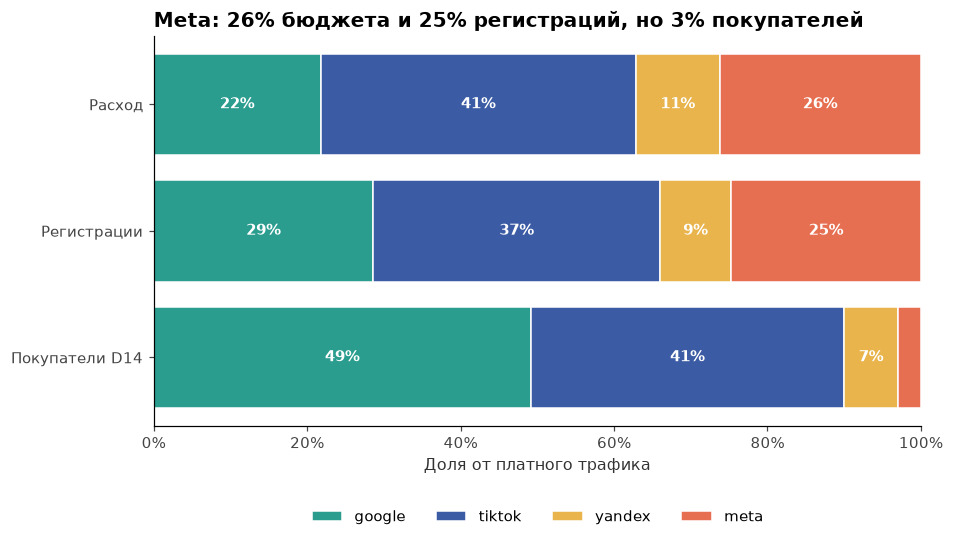

In [4]:
share = pd.DataFrame({
    "Расход": paid["spend"] / paid["spend"].sum(),
    "Регистрации": paid["regs"] / paid["regs"].sum(),
    "Покупатели D14": paid["buyers"] / paid["buyers"].sum(),
})
fig, ax = plt.subplots(figsize=(9, 4.6))
left = np.zeros(len(share.columns))
for p in ["google", "tiktok", "yandex", "meta"]:
    vals = share.loc[p].values
    ax.barh(share.columns, vals, left=left, color=pf.COLORS[p], label=p, edgecolor="white")
    for i, v in enumerate(vals):
        if v > 0.04:
            ax.text(left[i] + v / 2, i, f"{v:.0%}", ha="center", va="center", color="white", fontsize=9.5, fontweight="bold")
    left += vals
ax.invert_yaxis()
pf.pct_axis(ax, "x")
ax.set_xlim(0, 1)
ax.grid(False)
ax.set_xlabel("Доля от платного трафика")
m = share.loc["meta"]
ax.set_title(f"Meta: {m.iloc[0]:.0%} бюджета и {m.iloc[1]:.0%} регистраций, но {m.iloc[2]:.0%} покупателей")
ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.18))
pf.save(fig, "01_share_spend_regs_buyers")
plt.show()

## 3. Конверсия и стоимость покупателя

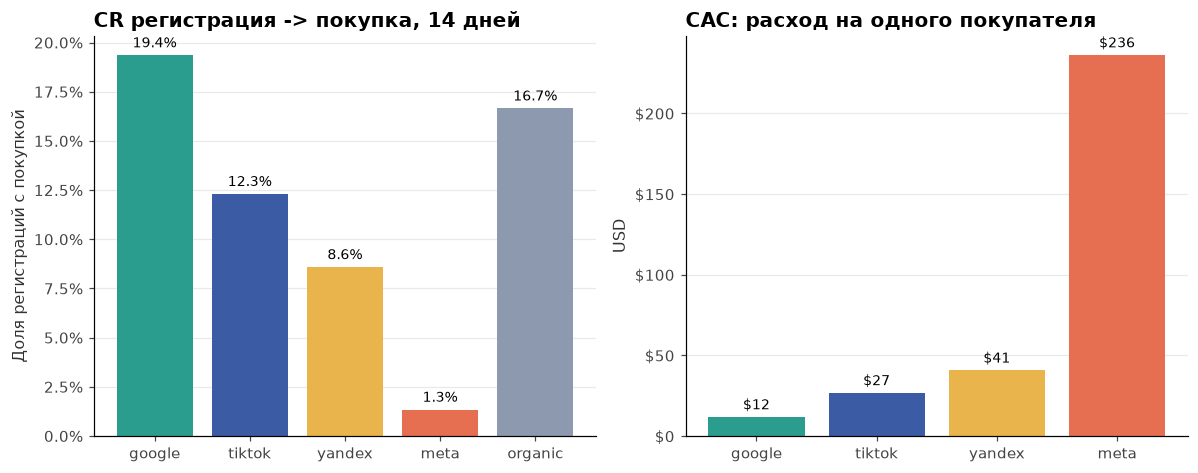

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
d = by_platform.loc[PLATFORMS]
axes[0].bar(d.index, d["cr_d14"], color=[pf.COLORS[p] for p in d.index])
pf.bar_labels(axes[0], "{:.1%}")
pf.pct_axis(axes[0])
axes[0].set_title("CR регистрация -> покупка, 14 дней")
axes[0].set_ylabel("Доля регистраций с покупкой")
d2 = by_platform.loc[["google", "tiktok", "yandex", "meta"]]
axes[1].bar(d2.index, d2["cac"], color=[pf.COLORS[p] for p in d2.index])
pf.bar_labels(axes[1], "${:.0f}")
pf.usd_axis(axes[1])
axes[1].set_title("CAC: расход на одного покупателя")
axes[1].set_ylabel("USD")
fig.tight_layout()
pf.save(fig, "02_cr_cac_by_platform")
plt.show()

## 4. LTV/CAC

За два месяца LTV не накопится, поэтому прогнозируем его: берём выручку когорты за 14 дней и умножаем на коэффициент "выручка за 365 дней / выручка за 14 дней", посчитанный по регистрациям сентября 2024 - августа 2025 той же платформы. У этих когорт уже прошло 12 месяцев.

LTV/CAC = прогнозная выручка за 12 месяцев на регистрацию / CPR. Это то же самое, что прогнозный ROAS за год. Считаем по выручке (стоимость доставки), без вычета себестоимости, поэтому порог окупаемости выше 1: при марже около 35% канал окупается от LTV/CAC примерно 3.

In [6]:
k = q("ltv_multiplier").set_index("platform")
k

,regs,arpu_d14,arpu_d365,k_365_to_14
platform,,,,
google,5993,3.46,10.91,3.15
meta,5054,0.20,0.72,3.52
organic,4484,3.12,9.60,3.08
tiktok,7491,2.29,7.16,3.13
yandex,2054,1.56,5.05,3.24


In [7]:
ltv = paid[["spend", "regs", "buyers", "revenue_d14", "cpr", "cac", "roas_d14"]].copy()
ltv["k_365_to_14"] = k.loc[ltv.index, "k_365_to_14"]
ltv["ltv12_per_reg"] = ltv["revenue_d14"] / ltv["regs"] * ltv["k_365_to_14"]
ltv["ltv_cac"] = ltv["ltv12_per_reg"] / ltv["cpr"]
ltv = ltv.sort_values("ltv_cac", ascending=False)
ltv

,spend,regs,buyers,revenue_d14,cpr,cac,roas_d14,k_365_to_14,ltv12_per_reg,ltv_cac
platform,,,,,,,,,,
google,"4,312.05","1,901.00",368.00,"6,293.14",2.27,11.72,1.46,3.15,10.43,4.60
tiktok,"8,131.15","2,478.00",305.00,"5,386.81",3.28,26.66,0.66,3.13,6.81,2.07
yandex,"2,154.09",617.00,53.00,"1,087.75",3.49,40.64,0.50,3.24,5.71,1.63
meta,"5,193.52","1,640.00",22.00,371.38,3.17,236.07,0.07,3.52,0.80,0.25


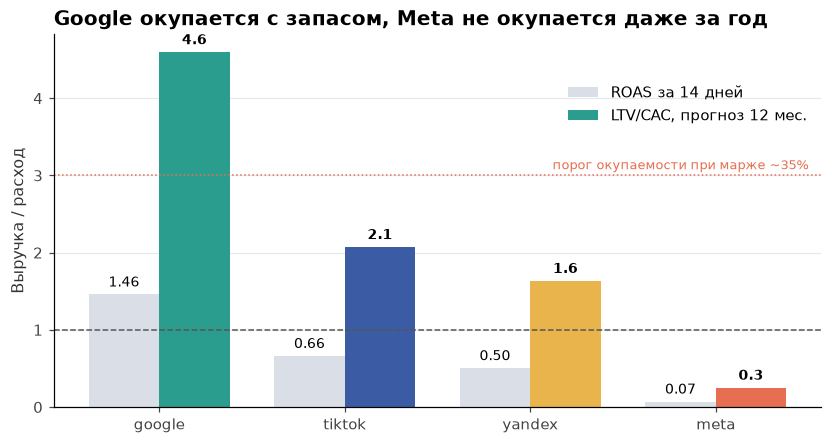

In [8]:
fig, ax = plt.subplots(figsize=(9, 4.4))
x = np.arange(len(ltv))
w = 0.38
b1 = ax.bar(x - w / 2, ltv["roas_d14"], w, color=pf.COLORS["light"], label="ROAS за 14 дней")
b2 = ax.bar(x + w / 2, ltv["ltv_cac"], w, color=[pf.COLORS[p] for p in ltv.index], label="LTV/CAC, прогноз 12 мес.")
ax.bar_label(b1, labels=[f"{v:.2f}" for v in ltv["roas_d14"]], padding=3, fontsize=9)
ax.bar_label(b2, labels=[f"{v:.1f}" for v in ltv["ltv_cac"]], padding=3, fontsize=9, fontweight="bold")
ax.axhline(1, color="#555555", lw=1, ls="--")
ax.axhline(3, color=pf.COLORS["accent"], lw=1, ls=":")
ax.text(len(ltv) - 0.5, 3.08, "порог окупаемости при марже ~35%", ha="right", fontsize=8.5, color=pf.COLORS["accent"])
ax.set_xticks(x, ltv.index)
ax.set_ylabel("Выручка / расход")
ax.set_title("Google окупается с запасом, Meta не окупается даже за год")
ax.legend(loc="upper right", bbox_to_anchor=(1, 0.9))
pf.save(fig, "03_roas_ltv_cac")
plt.show()

## 5. iOS против Android

In [9]:
os_sum = q("os_summary").set_index("os")
os_sum

,regs,cr_d14_all,cr_d14_paid,regs_paid,buyers_paid,spend,cpr,cac,roas_d14
os,,,,,,,,,
ios,2847,0.18,0.16,2262,366,"8,103.05",3.58,22.14,0.75
android,5338,0.09,0.09,4374,382,"11,687.76",2.67,30.60,0.60


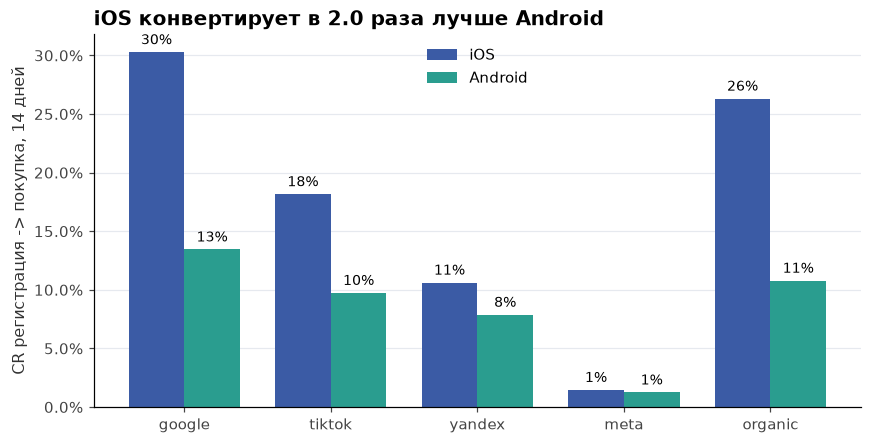

In [10]:
po = ue[(ue["os"] != "all") & (ue["platform"].isin(PLATFORMS))].pivot(index="platform", columns="os", values="cr_d14").loc[PLATFORMS]
fig, ax = plt.subplots(figsize=(9, 4.4))
x = np.arange(len(po))
w = 0.38
b1 = ax.bar(x - w / 2, po["ios"], w, color=pf.COLORS["ios"], label="iOS")
b2 = ax.bar(x + w / 2, po["android"], w, color=pf.COLORS["android"], label="Android")
ax.bar_label(b1, labels=[f"{v:.0%}" for v in po["ios"]], padding=3, fontsize=9)
ax.bar_label(b2, labels=[f"{v:.0%}" for v in po["android"]], padding=3, fontsize=9)
ax.set_xticks(x, po.index)
pf.pct_axis(ax)
ax.set_ylabel("CR регистрация -> покупка, 14 дней")
ratio = os_sum.loc["ios", "cr_d14_all"] / os_sum.loc["android", "cr_d14_all"]
ax.set_title(f"iOS конвертирует в {ratio:.1f} раза лучше Android")
ax.legend()
pf.save(fig, "04_cr_ios_android")
plt.show()

Разница не объясняется составом платформ: она есть внутри каждой, кроме Meta, где покупок почти нет на обеих ОС. При этом регистрация на iOS дороже, поэтому сравниваем CAC, а не только CR.

In [11]:
po_cac = ue[(ue["os"] != "all") & (ue["platform"].isin(["google", "tiktok", "yandex", "meta"]))].pivot(index="platform", columns="os", values="cac")
po_cac

os,android,ios
platform,,
google,15.13,8.91
meta,217.52,258.32
tiktok,30.40,22.07
yandex,40.52,40.91


## 6. Устойчивость: конверсия по неделям

Проверяем, что картина держится каждую неделю, а не сделана одной удачной неделей.

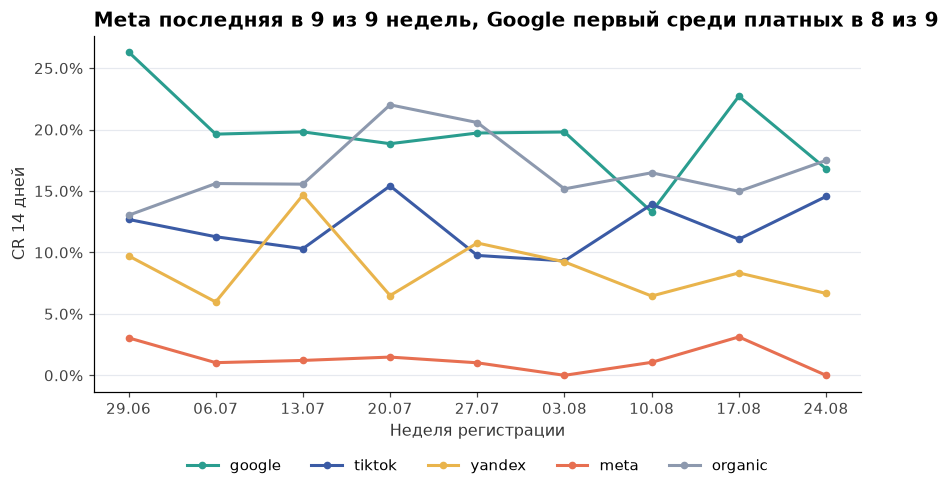

In [12]:
wk = q("weekly_trend").pivot(index="week", columns="platform", values="cr_d14")[PLATFORMS]
wk.index = pd.to_datetime(wk.index).strftime("%d.%m")
fig, ax = plt.subplots(figsize=(9, 4.2))
for p in PLATFORMS:
    ax.plot(wk.index, wk[p], marker="o", ms=4, lw=2, color=pf.COLORS[p], label=p)
pf.pct_axis(ax)
ax.set_ylabel("CR 14 дней")
ax.set_xlabel("Неделя регистрации")
paid_cols = ["google", "tiktok", "yandex", "meta"]
g_first = int((wk[paid_cols].idxmax(axis=1) == "google").sum())
m_last = int((wk[paid_cols].idxmin(axis=1) == "meta").sum())
ax.set_title(f"Meta последняя в {m_last} из {len(wk)} недель, Google первый среди платных в {g_first} из {len(wk)}")
ax.legend(ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.15))
pf.save(fig, "05_weekly_cr")
plt.show()

## 7. Сценарий перераспределения бюджета

Допущения: оставляем 20% бюджета Meta на тест ретаргетинга, остальное делим 60/40 между Google и TikTok. У дополнительных денег эффективность ниже средней: закладываем CAC выше текущего на 30% (убывающая отдача). Выручка на покупателя в канале не меняется.

In [13]:
cut = 0.8 * paid.loc["meta", "spend"]
moved = {"google": 0.6 * cut, "tiktok": 0.4 * cut}
rev_per_buyer = paid["revenue_d14"] / paid["buyers"]
scen = paid[["spend", "buyers", "revenue_d14"]].copy()
scen["spend_new"] = scen["spend"]
scen.loc["meta", "spend_new"] -= cut
extra_buyers = {}
for p, money in moved.items():
    scen.loc[p, "spend_new"] += money
    extra_buyers[p] = money / (paid.loc[p, "cac"] * 1.3)
scen["buyers_new"] = scen["buyers"]
scen.loc["meta", "buyers_new"] = scen.loc["meta", "buyers"] * 0.2
for p, b in extra_buyers.items():
    scen.loc[p, "buyers_new"] += b
scen["revenue_new"] = scen["buyers_new"] * rev_per_buyer
scen.loc["total"] = scen.sum()
scen

,spend,buyers,revenue_d14,spend_new,buyers_new,revenue_new
platform,,,,,,
google,"4,312.05",368.00,"6,293.14","6,804.94",531.65,"9,091.76"
tiktok,"8,131.15",305.00,"5,386.81","9,793.08",352.95,"6,233.74"
yandex,"2,154.09",53.00,"1,087.75","2,154.09",53.00,"1,087.75"
meta,"5,193.52",22.00,371.38,"1,038.70",4.40,74.28
total,"19,790.81",748.00,"13,139.08","19,790.81",942.01,"16,487.52"


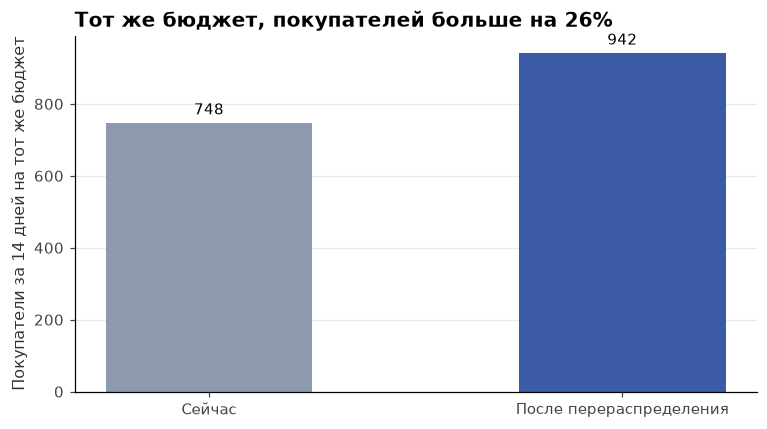

In [14]:
fig, ax = plt.subplots(figsize=(8, 4.2))
vals = [scen.loc["total", "buyers"], scen.loc["total", "buyers_new"]]
bars = ax.bar(["Сейчас", "После перераспределения"], vals, color=[pf.COLORS["muted"], pf.COLORS["main"]], width=0.5)
ax.bar_label(bars, labels=[f"{v:,.0f}" for v in vals], padding=3)
gain = vals[1] / vals[0] - 1
ax.set_ylabel("Покупатели за 14 дней на тот же бюджет")
ax.set_title(f"Тот же бюджет, покупателей больше на {gain:.0%}")
pf.save(fig, "06_reallocation")
plt.show()

## 8. Ключевые числа для README

In [15]:
res = {
    "paid_spend": paid_total["spend"],
    "paid_regs": paid_total["regs"],
    "paid_cac": paid_total["cac"],
    "paid_roas_d14": paid_total["roas_d14"],
}
for p in PLATFORMS:
    res[f"{p}_regs"] = by_platform.loc[p, "regs"]
    res[f"{p}_cr"] = by_platform.loc[p, "cr_d14"]
    if p != "organic":
        res[f"{p}_spend"] = by_platform.loc[p, "spend"]
        res[f"{p}_cpi"] = by_platform.loc[p, "cpi"]
        res[f"{p}_cpr"] = by_platform.loc[p, "cpr"]
        res[f"{p}_cac"] = by_platform.loc[p, "cac"]
        res[f"{p}_roas"] = by_platform.loc[p, "roas_d14"]
        res[f"{p}_ltv_cac"] = ltv.loc[p, "ltv_cac"]
        res[f"{p}_share_spend"] = share.loc[p, "Расход"]
        res[f"{p}_share_regs"] = share.loc[p, "Регистрации"]
        res[f"{p}_share_buyers"] = share.loc[p, "Покупатели D14"]
res["weeks"] = len(wk)
res["weeks_google_first"] = g_first
res["weeks_meta_last"] = m_last
res["ios_cr"] = os_sum.loc["ios", "cr_d14_all"]
res["android_cr"] = os_sum.loc["android", "cr_d14_all"]
res["ios_android_ratio"] = ratio
res["ios_cac"] = os_sum.loc["ios", "cac"]
res["android_cac"] = os_sum.loc["android", "cac"]
res["ios_cpr"] = os_sum.loc["ios", "cpr"]
res["android_cpr"] = os_sum.loc["android", "cpr"]
res["realloc_cut"] = cut
res["realloc_buyers_now"] = scen.loc["total", "buyers"]
res["realloc_buyers_new"] = scen.loc["total", "buyers_new"]
res["realloc_gain"] = gain
pf.save_results(res)
pd.Series(res)

paid_spend           19,790.81
paid_regs             6,636.00
paid_cac                 26.46
paid_roas_d14             0.66
google_regs           1,901.00
                        ...   
android_cpr               2.67
realloc_cut           4,154.82
realloc_buyers_now      748.00
realloc_buyers_new      942.01
realloc_gain              0.26
Length: 64, dtype: float64